# RNAseq data cleanup

loading the needed libraries and the data

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [44]:
from pathlib import Path
mmc2_path = Path('data') / 'mmc2.csv'
rna_seq_data = pd.read_csv(mmc2_path)
rna_seq_data.head()

,Unnamed: 0,LTHSC.34-.BM,LTHSC.34+.BM,STHSC.150-.BM,MPP4.135+.BM,proB.CLP.BM,proB.FrA.BM,proB.FrBC.BM,B.FrE.BM,B1b.PC,...,MF.PC,MF.Fem.PC,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
0,0610005C13Rik,1.096732,1.096732,1.021750,1.021812,1.205236,1.326780,1.392996,1.821243,1.025543,...,1.025785,1.025785,1.251082,1.147249,1.024462,1.019656,1.017884,1.019107,1.017884,1.024720
1,0610007P14Rik,206.053987,246.105317,192.424636,204.298358,189.759175,210.195155,180.219440,137.802543,139.436719,...,121.603448,105.140895,101.841463,175.620707,280.406964,200.228029,208.171821,88.578590,129.021874,140.655763
2,0610009B22Rik,78.272059,78.837030,68.844751,76.418169,106.085619,77.502817,68.213092,57.224426,56.787489,...,88.691426,73.423656,68.881268,60.811907,56.578015,100.397766,37.373080,73.888468,77.191831,84.245816
3,0610009L18Rik,8.577159,16.791386,15.511549,16.947354,10.583704,8.664784,2.878172,8.952120,11.873984,...,6.132818,8.965889,4.080445,11.987408,5.627219,4.227673,2.199352,1.460090,2.482516,1.023995
4,0610009O20Rik,168.645852,157.926022,155.941641,186.261464,162.584556,152.088002,163.072291,133.116083,88.052982,...,102.592399,147.139323,130.924354,107.542142,88.338330,100.779150,86.442408,193.307175,187.212720,45.464889


## an explorativ overview of the data

In [45]:
print(rna_seq_data.describe())
print(rna_seq_data.isnull().sum())
print(rna_seq_data.nunique())

       LTHSC.34-.BM  LTHSC.34+.BM  STHSC.150-.BM  MPP4.135+.BM   proB.CLP.BM  \
count  17535.000000  17535.000000   17535.000000  17535.000000  17535.000000   
mean     163.261162    163.261089     163.260318    163.260179    163.258616   
std      576.884525    576.925735     577.574457    577.409321    571.296896   
min        1.020795      1.021260       1.021750      1.021812      1.023171   
25%        1.196112      1.185784       1.170825      1.136401      1.186354   
50%       22.788066     23.117322      23.353421     22.886122     23.643738   
75%      144.402771    144.214802     142.951482    144.204604    144.325627   
max    28264.930700  28264.930700   28264.930700  28264.930700  28264.930700   

        proB.FrA.BM  proB.FrBC.BM      B.FrE.BM        B1b.PC       B.T1.Sp  \
count  17535.000000  17535.000000  17535.000000  17535.000000  17535.000000   
mean     163.260821    163.250902    163.230389    163.231197    163.240847   
std      572.986929    576.360614    577.4

The data set has all of the gene names in the first column and then for 86 different cell types their specific expression value for each gene.

In [46]:
rna_seq_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 17535 entries, 0 to 17534
Data columns (total 87 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             17535 non-null  str    
 1   LTHSC.34-.BM           17535 non-null  float64
 2   LTHSC.34+.BM           17535 non-null  float64
 3   STHSC.150-.BM          17535 non-null  float64
 4   MPP4.135+.BM           17535 non-null  float64
 5   proB.CLP.BM            17535 non-null  float64
 6   proB.FrA.BM            17535 non-null  float64
 7   proB.FrBC.BM           17535 non-null  float64
 8   B.FrE.BM               17535 non-null  float64
 9   B1b.PC                 17535 non-null  float64
 10  B.T1.Sp                17535 non-null  float64
 11  B.T2.Sp                17535 non-null  float64
 12  B.T3.Sp                17535 non-null  float64
 13  B.Sp                   17535 non-null  float64
 14  B.Fem.Sp               17535 non-null  float64
 15  B.MZ.Sp      

some additional libraries for plotting

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

### Creating a histogram of one cell type as an example

<Axes: xlabel='Tgd.g2+d17.LN', ylabel='Count'>

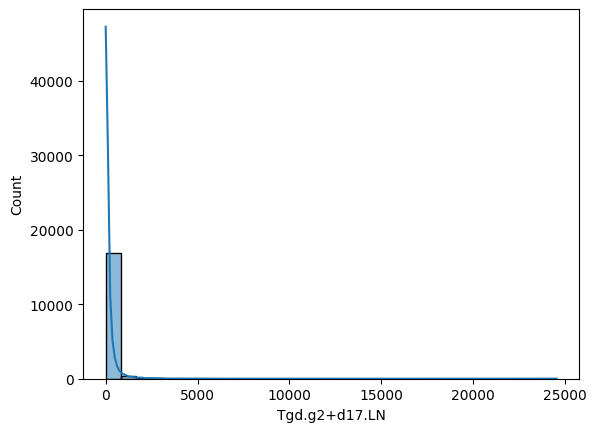

In [48]:
sns.histplot(rna_seq_data["Tgd.g2+d17.LN"], bins=30, kde=True)

Because the histogram does not show any usefull information in the normal scale, I will perform a log-transformation of all RNAseq values and create a new data frame with them

In [49]:
numeric_cols = rna_seq_data.select_dtypes(include=[np.number]).columns
print(numeric_cols)

Index(['LTHSC.34-.BM', 'LTHSC.34+.BM', 'STHSC.150-.BM', 'MPP4.135+.BM',
       'proB.CLP.BM', 'proB.FrA.BM', 'proB.FrBC.BM', 'B.FrE.BM', 'B1b.PC',
       'B.T1.Sp', 'B.T2.Sp', 'B.T3.Sp', 'B.Sp', 'B.Fem.Sp', 'B.MZ.Sp',
       'B.Fo.Sp', 'B.mem.Sp', 'B.GC.CB.Sp', 'B.GC.CC.Sp', 'B.PB.Sp', 'B.PC.Sp',
       'B.PC.BM', 'preT.DN1.Th', 'preT.DN2a.Th', 'preT.DN2b.Th', 'preT.DN3.Th',
       'T.DN4.Th', 'T.ISP.Th', 'T.DP.Th', 'T.4.Th', 'T.8.Th', 'T.4.Nve.Sp',
       'T.4.Nve.Fem.Sp', 'T.8.Nve.Sp', 'T.4.Sp.aCD3+CD40.18hr',
       'Treg.4.FP3+.Nrplo.Co', 'Treg.4.25hi.Sp', 'T8.TN.P14.Sp',
       'T8.IEL.LCMV.d7.Gut', 'T8.TE.LCMV.d7.Sp', 'T8.MP.LCMV.d7.Sp',
       'T8.Tcm.LCMV.d180.Sp', 'T8.Tem.LCMV.d180.Sp', 'NKT.Sp',
       'NKT.Sp.LPS.3hr', 'NKT.Sp.LPS.18hr', 'NKT.Sp.LPS.3d',
       'Tgd.g2+d17.24a+.Th', 'Tgd.g2+d17.LN', 'Tgd.g2+d1.24a+.Th',
       'Tgd.g2+d1.LN', 'Tgd.g1.1+d1.24a+.Th', 'Tgd.g1.1+d1.LN', 'Tgd.Sp',
       'NK.27+11b-.BM', 'NK.27+11b+.BM', 'NK.27-11b+.BM', 'NK.27+11b-.Sp',
       '

In [50]:
log_rna_seq = rna_seq_data.copy()
log_rna_seq[numeric_cols] = np.log1p(log_rna_seq[numeric_cols])
log_rna_seq.head()

,Unnamed: 0,LTHSC.34-.BM,LTHSC.34+.BM,STHSC.150-.BM,MPP4.135+.BM,proB.CLP.BM,proB.FrA.BM,proB.FrBC.BM,B.FrE.BM,B1b.PC,...,MF.PC,MF.Fem.PC,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
0,0610005C13Rik,0.740380,0.740380,0.703964,0.703994,0.790834,0.844485,0.872546,1.037178,0.705838,...,0.705957,0.705957,0.811411,0.764187,0.705304,0.702927,0.702050,0.702655,0.702050,0.705431
1,0610007P14Rik,5.332980,5.509815,5.264888,5.324464,5.251012,5.352783,5.199709,4.933052,4.944757,...,4.808955,4.664767,4.633189,5.174005,5.639802,5.304439,5.343156,4.495116,4.867703,4.953400
2,0610009B22Rik,4.372886,4.379987,4.246275,4.349221,4.673629,4.363135,4.237190,4.064305,4.056772,...,4.496375,4.309774,4.246798,4.124096,4.053141,4.619051,3.647356,4.316000,4.359165,4.445539
3,0610009L18Rik,2.259381,2.878714,2.804060,2.887443,2.449599,2.268489,1.355364,2.297786,2.555209,...,1.964706,2.299168,1.625399,2.563980,1.891185,1.653966,1.162948,0.900198,1.247755,0.705073
4,0610009O20Rik,5.133713,5.068439,5.055874,5.232506,5.097330,5.031013,5.100307,4.898706,4.489231,...,4.640464,4.998153,4.882229,4.687139,4.492431,4.622805,4.470980,5.269440,5.237573,3.838697


<Axes: xlabel='Tgd.g2+d17.LN', ylabel='Count'>

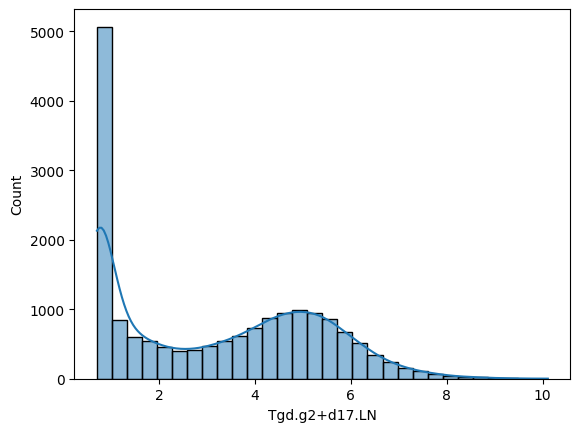

In [51]:
sns.histplot(log_rna_seq["Tgd.g2+d17.LN"], bins=30, kde=True)

After the log transformation there is more usefull information visible in the histogram

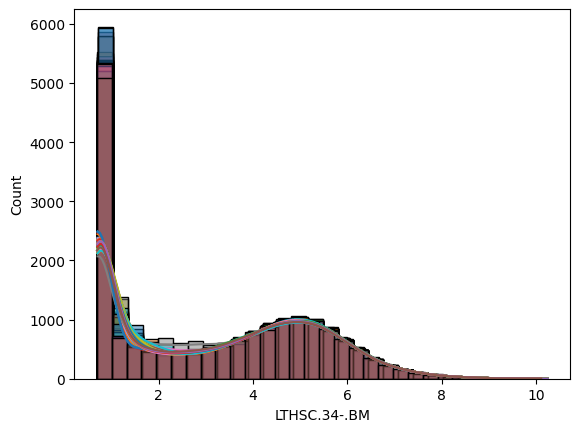

In [52]:
for  x in numeric_cols:
    sns.histplot(log_rna_seq[x], bins=30, kde=True)

### Creating new data frames with only those cell types relevant to us

In [53]:
Tgd_cells = ["Unnamed: 0" ,
            "MPP4.135+.BM" ,
            "preT.DN1.Th" ,
            "preT.DN2a.Th" ,
            "preT.DN2b.Th" ,
            "preT.DN3.Th" ,
            "T.DN4.Th" ,
            "Tgd.g1.1+d1.24a+.Th" ,
            "Tgd.g2+d1.24a+.Th" ,
            "Tgd.g2+d17.24a+.Th" ,
            "Tgd.Sp" ,
            "Tgd.g1.1+d1.LN" ,
            "Tgd.g2+d1.LN" ,
            "Tgd.g2+d17.LN"
            ]

In [54]:
Tgd_rna = rna_seq_data[Tgd_cells].copy()
Tgd_rna.head()
log_Tgd_rna = log_rna_seq[Tgd_cells].copy()
log_Tgd_rna.head()

,Unnamed: 0,MPP4.135+.BM,preT.DN1.Th,preT.DN2a.Th,preT.DN2b.Th,preT.DN3.Th,T.DN4.Th,Tgd.g1.1+d1.24a+.Th,Tgd.g2+d1.24a+.Th,Tgd.g2+d17.24a+.Th,Tgd.Sp,Tgd.g1.1+d1.LN,Tgd.g2+d1.LN,Tgd.g2+d17.LN
0,0610005C13Rik,0.703994,0.704267,0.871188,0.705480,0.705314,0.706275,0.705073,0.773602,0.705480,0.705073,0.705838,0.705480,0.705073
1,0610007P14Rik,5.324464,5.097676,5.337275,5.348001,5.295420,5.375540,5.022182,5.164966,4.761581,4.921445,4.699120,4.641516,4.933934
2,0610009B22Rik,4.349221,4.235131,4.424473,4.508322,4.071786,4.348977,3.887223,3.828218,3.997487,3.771375,3.393010,3.114299,3.405284
3,0610009L18Rik,2.887443,2.800369,2.679237,2.736159,2.224568,0.987000,2.257064,2.280540,3.406405,2.296328,2.469397,2.416107,2.305915
4,0610009O20Rik,5.232506,5.082933,4.840047,5.055787,4.801501,4.782761,4.554537,4.741455,4.639046,4.385958,4.450194,4.674574,4.470305


RNAseq data only containing cell types relevant to us

## Filtering out low expression / noise

Low values <1.5 are not due to a detectable expression level, but are rather caused by noise. Thereby they can be disregarded.

In [55]:
noise_frac = (rna_seq_data[numeric_cols] < 1.5).sum() / rna_seq_data.shape[0]
print(noise_frac)

LTHSC.34-.BM     0.286741
LTHSC.34+.BM     0.288680
STHSC.150-.BM    0.286285
MPP4.135+.BM     0.287197
proB.CLP.BM      0.290676
                   ...   
FRC.SLN          0.287539
IAP.SLN          0.276362
BEC.SLN          0.281665
LEC.SLN          0.285714
Ep.MEChi.Th      0.275620
Length: 86, dtype: float64


How much of the RNAseq data is noise?

In [56]:
print(noise_frac.mean())

0.27943780213659064


plotting the noise fraction for each cell type

Text(0.5, 1.0, 'Noise fraction per cell type')

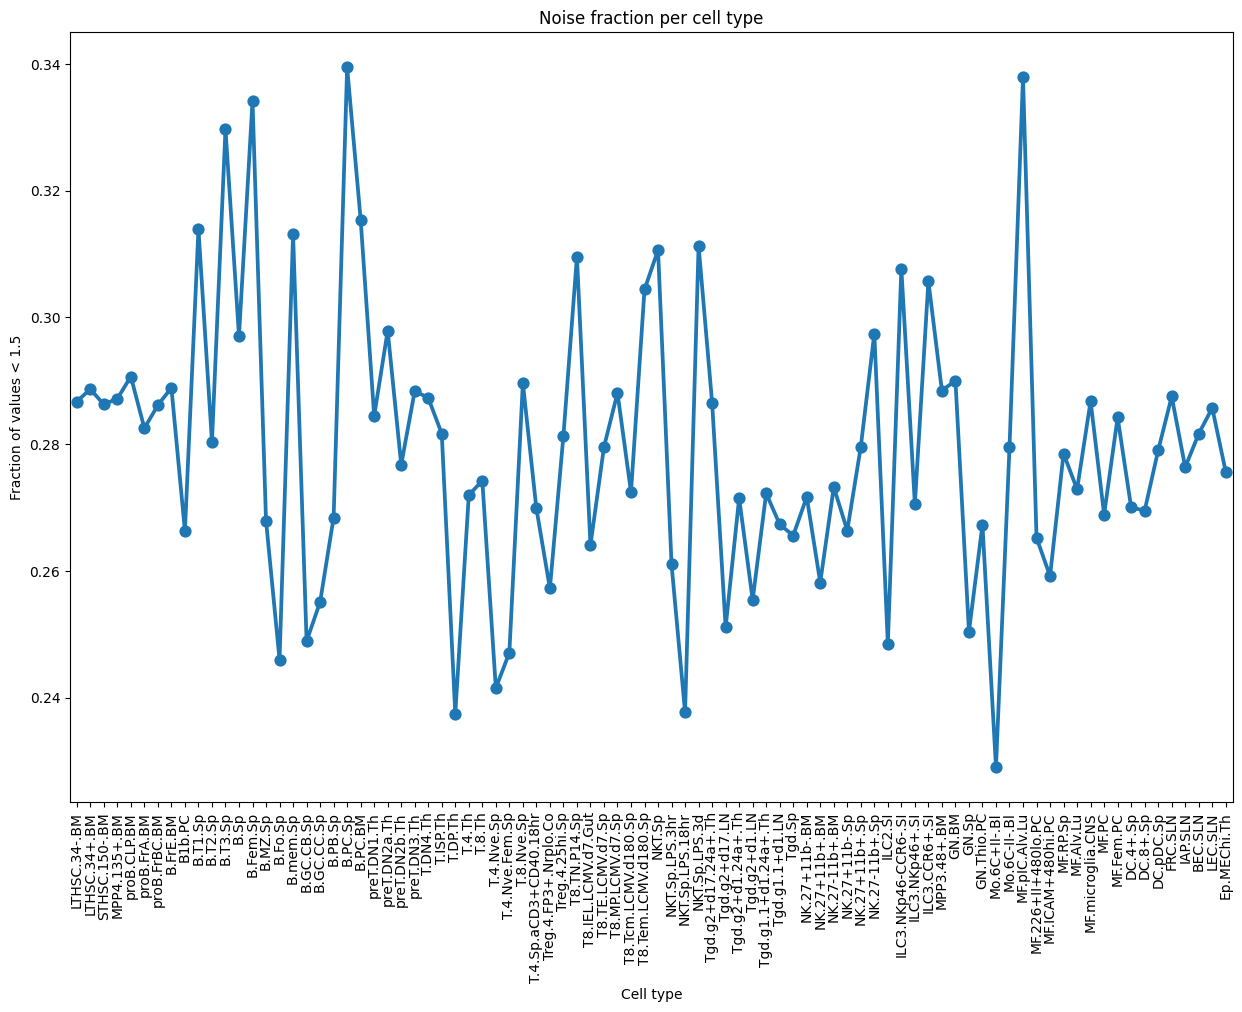

In [57]:
noise_frac_df = noise_frac.reset_index()
noise_frac_df.columns = ['cell_type', 'noise_fraction']

plt.figure(figsize=(15, 10))
sns.pointplot(data=noise_frac_df, x='cell_type', y='noise_fraction')
plt.xticks(rotation=90)
plt.ylabel('Fraction of values < 1.5')
plt.xlabel('Cell type')
plt.title('Noise fraction per cell type')

27.9% of all values are under the threshold of 1.5 and 31.1% under a threshold of 2. 
The fraction of low expressed Genes is similar over all cell types.

How many genes are expressed in more than 10% of all cell types?

In [58]:
(((rna_seq_data.iloc[:, 1:] < 1.5).sum(axis=1) / 86) < 0.1).sum()


np.int64(9708)

### filtering out genes which are only expressed in less than 25 % of cell types

In [59]:
gene_expr_frac = (rna_seq_data.iloc[:, 1:] > 1.5).sum(axis=1) / (rna_seq_data.shape[1] - 1)
rna_seq_filtered = rna_seq_data[rna_seq_data.index.isin(gene_expr_frac[gene_expr_frac >= 0.25].index)].copy()
rna_seq_filtered.info()

<class 'pandas.DataFrame'>
Index: 14417 entries, 1 to 17534
Data columns (total 87 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             14417 non-null  str    
 1   LTHSC.34-.BM           14417 non-null  float64
 2   LTHSC.34+.BM           14417 non-null  float64
 3   STHSC.150-.BM          14417 non-null  float64
 4   MPP4.135+.BM           14417 non-null  float64
 5   proB.CLP.BM            14417 non-null  float64
 6   proB.FrA.BM            14417 non-null  float64
 7   proB.FrBC.BM           14417 non-null  float64
 8   B.FrE.BM               14417 non-null  float64
 9   B1b.PC                 14417 non-null  float64
 10  B.T1.Sp                14417 non-null  float64
 11  B.T2.Sp                14417 non-null  float64
 12  B.T3.Sp                14417 non-null  float64
 13  B.Sp                   14417 non-null  float64
 14  B.Fem.Sp               14417 non-null  float64
 15  B.MZ.Sp           

In [60]:
rna_seq_rare_genes = rna_seq_data[rna_seq_data.index.isin(gene_expr_frac[gene_expr_frac < 0.25].index)].copy()
rna_seq_rare_genes.info()

<class 'pandas.DataFrame'>
Index: 3118 entries, 0 to 17533
Data columns (total 87 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             3118 non-null   str    
 1   LTHSC.34-.BM           3118 non-null   float64
 2   LTHSC.34+.BM           3118 non-null   float64
 3   STHSC.150-.BM          3118 non-null   float64
 4   MPP4.135+.BM           3118 non-null   float64
 5   proB.CLP.BM            3118 non-null   float64
 6   proB.FrA.BM            3118 non-null   float64
 7   proB.FrBC.BM           3118 non-null   float64
 8   B.FrE.BM               3118 non-null   float64
 9   B1b.PC                 3118 non-null   float64
 10  B.T1.Sp                3118 non-null   float64
 11  B.T2.Sp                3118 non-null   float64
 12  B.T3.Sp                3118 non-null   float64
 13  B.Sp                   3118 non-null   float64
 14  B.Fem.Sp               3118 non-null   float64
 15  B.MZ.Sp            

This data frame contains the genes, which were filtered out and are only expressed in a few cell types

## Creating a function for log-tranformation

In [61]:
def log_transform(df):
    df_numeric_cols = df.select_dtypes(include=[np.number]).columns
    log_df = df.copy()
    log_df[df_numeric_cols] = np.log1p(log_df[df_numeric_cols])
    return log_df

### Using the log_transform function on the filtered values and creating a histogram

In [62]:
log_rna_filtered = log_transform(rna_seq_filtered)
log_rna_filtered.head()

,Unnamed: 0,LTHSC.34-.BM,LTHSC.34+.BM,STHSC.150-.BM,MPP4.135+.BM,proB.CLP.BM,proB.FrA.BM,proB.FrBC.BM,B.FrE.BM,B1b.PC,...,MF.PC,MF.Fem.PC,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
1,0610007P14Rik,5.332980,5.509815,5.264888,5.324464,5.251012,5.352783,5.199709,4.933052,4.944757,...,4.808955,4.664767,4.633189,5.174005,5.639802,5.304439,5.343156,4.495116,4.867703,4.953400
2,0610009B22Rik,4.372886,4.379987,4.246275,4.349221,4.673629,4.363135,4.237190,4.064305,4.056772,...,4.496375,4.309774,4.246798,4.124096,4.053141,4.619051,3.647356,4.316000,4.359165,4.445539
3,0610009L18Rik,2.259381,2.878714,2.804060,2.887443,2.449599,2.268489,1.355364,2.297786,2.555209,...,1.964706,2.299168,1.625399,2.563980,1.891185,1.653966,1.162948,0.900198,1.247755,0.705073
4,0610009O20Rik,5.133713,5.068439,5.055874,5.232506,5.097330,5.031013,5.100307,4.898706,4.489231,...,4.640464,4.998153,4.882229,4.687139,4.492431,4.622805,4.470980,5.269440,5.237573,3.838697
5,0610010F05Rik,4.342950,5.154307,4.788795,5.167947,4.696330,4.648626,4.666831,3.217680,3.481114,...,5.043096,5.127537,4.008402,4.183584,4.067938,2.470504,4.144515,4.664921,4.151987,5.164701


<Axes: xlabel='Tgd.g2+d17.LN', ylabel='Count'>

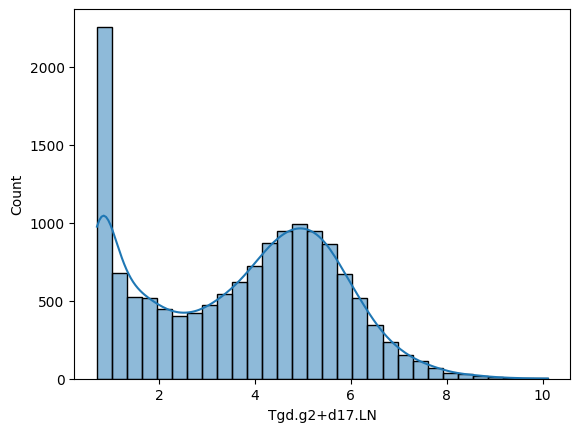

In [63]:
sns.histplot(log_rna_filtered["Tgd.g2+d17.LN"], bins=30, kde=True)

## Combination of filtering rarely expressed genes and genes with a low max expression

In [64]:
gene_max = rna_seq_data.iloc[:, 1:].max(axis=1)
print(gene_max)
mask = (gene_expr_frac >= 0.25) & (gene_max >= 10)
rna_filtered_2 = rna_seq_data[mask].copy()
rna_filtered_2.info()

0           5.893468
1         317.547722
2         106.085619
3          35.571948
4         291.548347
            ...     
17530    2987.564700
17531     598.913485
17532     419.023923
17533      12.301550
17534     242.887242
Length: 17535, dtype: float64
<class 'pandas.DataFrame'>
Index: 14077 entries, 1 to 17534
Data columns (total 87 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             14077 non-null  str    
 1   LTHSC.34-.BM           14077 non-null  float64
 2   LTHSC.34+.BM           14077 non-null  float64
 3   STHSC.150-.BM          14077 non-null  float64
 4   MPP4.135+.BM           14077 non-null  float64
 5   proB.CLP.BM            14077 non-null  float64
 6   proB.FrA.BM            14077 non-null  float64
 7   proB.FrBC.BM           14077 non-null  float64
 8   B.FrE.BM               14077 non-null  float64
 9   B1b.PC                 14077 non-null  float64
 10  B.T1.Sp          

Ceck if any rarely expressed genes have high expression in one cell type

In [65]:
rna_seq_rare_genes[gene_max >= 10].info()

<class 'pandas.DataFrame'>
Index: 1797 entries, 42 to 17533
Data columns (total 87 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             1797 non-null   str    
 1   LTHSC.34-.BM           1797 non-null   float64
 2   LTHSC.34+.BM           1797 non-null   float64
 3   STHSC.150-.BM          1797 non-null   float64
 4   MPP4.135+.BM           1797 non-null   float64
 5   proB.CLP.BM            1797 non-null   float64
 6   proB.FrA.BM            1797 non-null   float64
 7   proB.FrBC.BM           1797 non-null   float64
 8   B.FrE.BM               1797 non-null   float64
 9   B1b.PC                 1797 non-null   float64
 10  B.T1.Sp                1797 non-null   float64
 11  B.T2.Sp                1797 non-null   float64
 12  B.T3.Sp                1797 non-null   float64
 13  B.Sp                   1797 non-null   float64
 14  B.Fem.Sp               1797 non-null   float64
 15  B.MZ.Sp           

/var/folders/nl/0lggqn6d7qgdn8q_wz9ph3600000gn/T/ipykernel_18749/3520282910.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  rna_seq_rare_genes[gene_max >= 10].info()


plotting the filtered data to see how its distribution changed

<Axes: xlabel='Tgd.g2+d17.LN', ylabel='Count'>

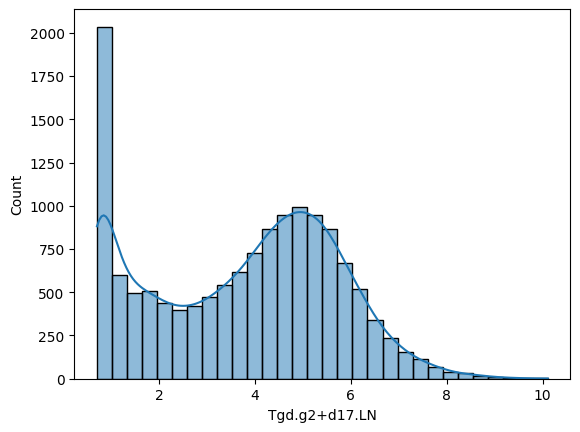

In [66]:
log_rna_filtered_2 = log_transform(rna_filtered_2)
sns.histplot(log_rna_filtered_2["Tgd.g2+d17.LN"], bins=30, kde=True)

## Only an absolute filter

An absolute filter seemed to be the most useful, because genes being rarely expressed could be cell type specifc markers and should not be filtered out.

<class 'pandas.DataFrame'>
Index: 15874 entries, 1 to 17534
Data columns (total 87 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             15874 non-null  str    
 1   LTHSC.34-.BM           15874 non-null  float64
 2   LTHSC.34+.BM           15874 non-null  float64
 3   STHSC.150-.BM          15874 non-null  float64
 4   MPP4.135+.BM           15874 non-null  float64
 5   proB.CLP.BM            15874 non-null  float64
 6   proB.FrA.BM            15874 non-null  float64
 7   proB.FrBC.BM           15874 non-null  float64
 8   B.FrE.BM               15874 non-null  float64
 9   B1b.PC                 15874 non-null  float64
 10  B.T1.Sp                15874 non-null  float64
 11  B.T2.Sp                15874 non-null  float64
 12  B.T3.Sp                15874 non-null  float64
 13  B.Sp                   15874 non-null  float64
 14  B.Fem.Sp               15874 non-null  float64
 15  B.MZ.Sp           

<Axes: xlabel='Tgd.g2+d17.LN', ylabel='Count'>

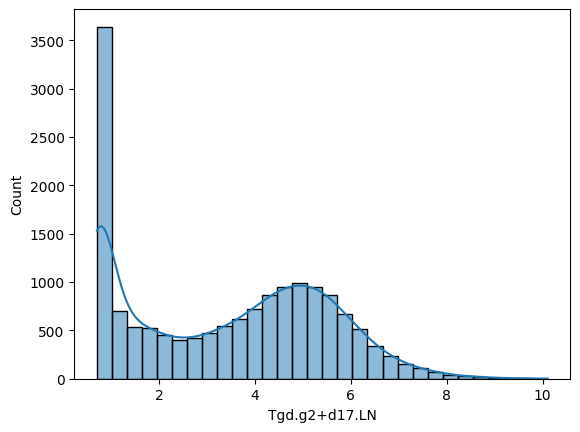

In [67]:
rna_filtered_absolute = rna_seq_data[rna_seq_data.iloc[:, 1:].max(axis=1) >= 10].copy()
rna_filtered_absolute.info()
log_rna_filtered_absolute = log_transform(rna_filtered_absolute)
sns.histplot(log_rna_filtered_absolute["Tgd.g2+d17.LN"], bins=30, kde=True)

## Filtering by Variation

First I have checked how the variation is distributed.

<Axes: ylabel='Count'>

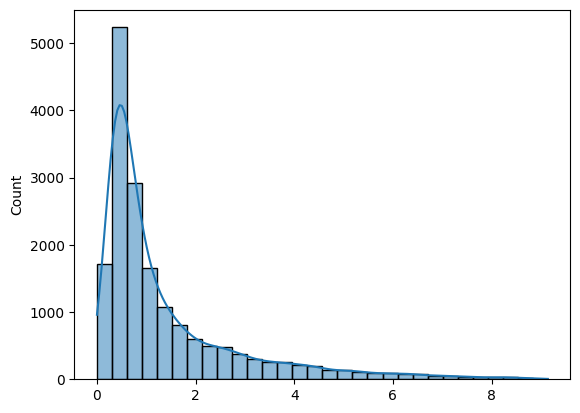

In [68]:
gene_var_coef = rna_seq_data.iloc[:, 1:].std(axis=1) / rna_seq_data.iloc[:, 1:].mean(axis=1)
sns.histplot(gene_var_coef, bins=30, kde=True)

filtering out genes with a low variation coefficiant (lowest 40%)

In [69]:
var_coef_threshold = gene_var_coef.quantile(0.40)
rna_variable_genes = rna_seq_data[gene_var_coef >= var_coef_threshold].copy()

Creating a separate data frame only with genes, that have a high varaiation coefficiant (top 1000), because these could be useful to distinguish between cell types.

In [70]:
top1000_threshold = gene_var_coef.nlargest(1000).index
rna_var_top1000 = rna_seq_data.loc[top1000_threshold].copy()

These scatter plots should visualize the effekt of the filtering and also reveal a potential releationship between mean expression and variation.

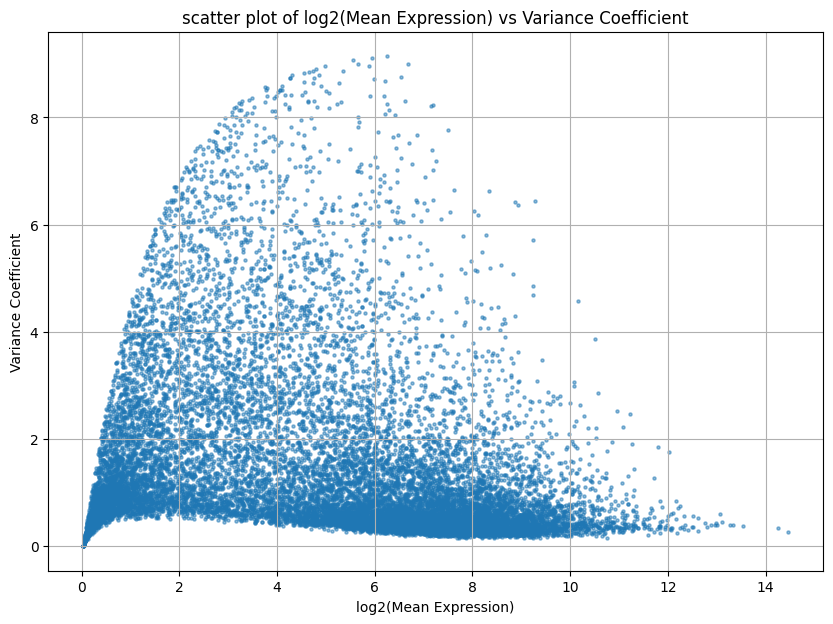

In [71]:
plt.figure(figsize=(10,7))
plt.scatter(np.log2(rna_seq_data.iloc[:, 1:].mean(axis=1)), gene_var_coef, s=5, alpha=0.5)
plt.xlabel('log2(Mean Expression)')
plt.ylabel('Variance Coefficient')
plt.title('scatter plot of log2(Mean Expression) vs Variance Coefficient')
plt.grid(True)
plt.show()

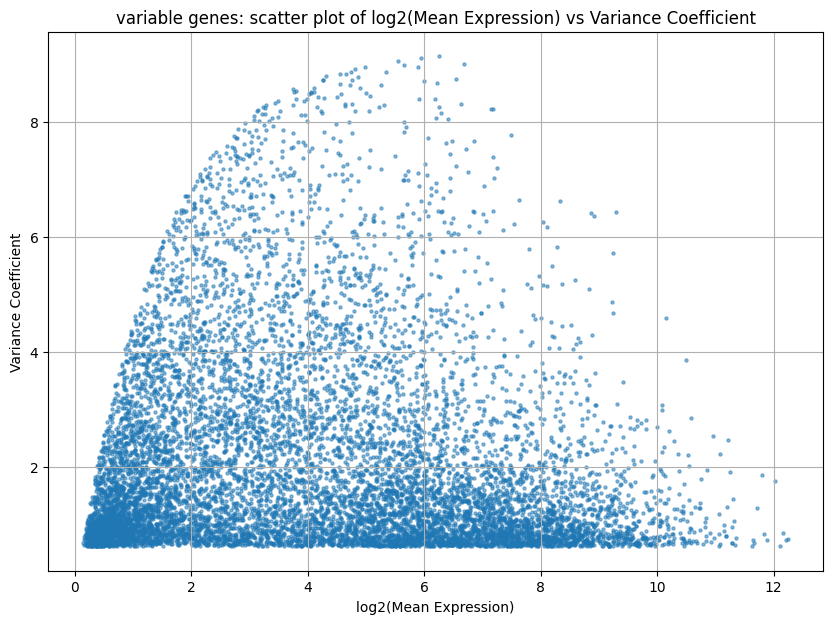

In [72]:
plt.figure(figsize=(10,7))
plt.scatter(np.log2(rna_variable_genes.iloc[:, 1:].mean(axis=1)), rna_variable_genes.iloc[:, 1:].std(axis=1) / rna_variable_genes.iloc[:, 1:].mean(axis=1), s=5, alpha=0.5)
plt.xlabel('log2(Mean Expression)')
plt.ylabel('Variance Coefficient')
plt.title('variable genes: scatter plot of log2(Mean Expression) vs Variance Coefficient')
plt.grid(True)
plt.show()

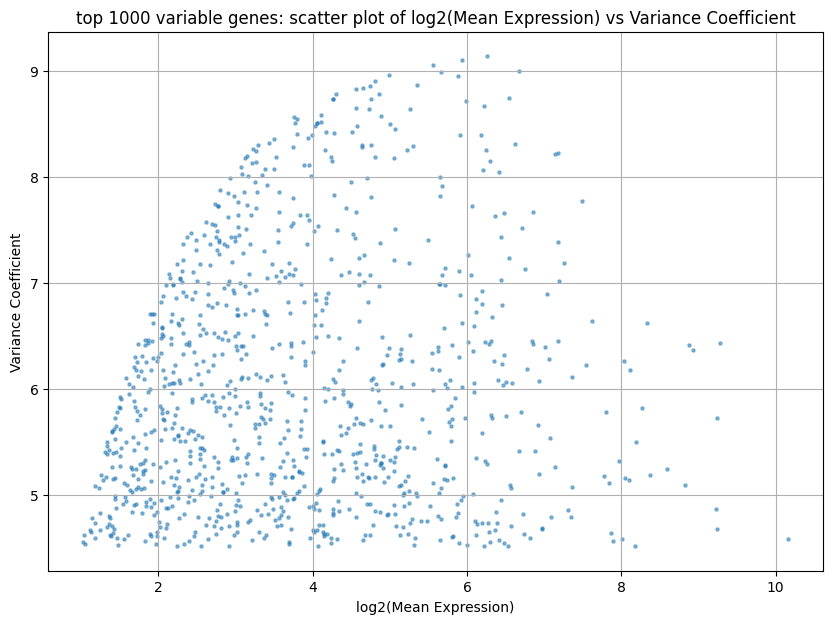

In [73]:
plt.figure(figsize=(10,7))
plt.scatter(np.log2(rna_var_top1000.iloc[:, 1:].mean(axis=1)), rna_var_top1000.iloc[:, 1:].std(axis=1) / rna_var_top1000.iloc[:, 1:].mean(axis=1), s=5, alpha=0.5)
plt.xlabel('log2(Mean Expression)')
plt.ylabel('Variance Coefficient')
plt.title('top 1000 variable genes: scatter plot of log2(Mean Expression) vs Variance Coefficient')
plt.grid(True)
plt.show()

<div class="alert alert-block alert-info">
<b>Conclusion</b> The RNA-seq data provided is already filtered and usable. Additional filtering only leads to a loss of information. Therefore we did not apply any of filtering methods for further analysis.
</div>

## Coloring the scatter plot to visualize gene functions

The scatter plot from before shows a good distribution of genes. It would be interesting to see if genes with similar functions group together (e.g. housekeeping genes could have low variation and therefore should be at the bottom).

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import gseapy as gp
from pathlib import Path
mmc2_path = Path('data') / 'mmc2.csv'
rna_seq_data = pd.read_csv(mmc2_path)
gene_var_coef = rna_seq_data.iloc[:, 1:].std(axis=1) / rna_seq_data.iloc[:, 1:].mean(axis=1)

I have first loaded the needed libraries and to determine the gene function I will be using the GO gene annotations

In [75]:
go_genesets = gp.get_library(name='GO_Biological_Process_2023', organism='Mouse')

instead of every gene in one category (default in the GO gene annotations), it is better to have every category for each gene

In [76]:
gene2terms = {}
for term, genes in go_genesets.items():
    for gene in genes:
        gene2terms.setdefault(gene, set()).add(term)


the categories are put into broader categories ("ribosom" can match "ribosome" and "ribosomal")

In [77]:
category_keywords = {
    "housekeeping":  ["ribosom", "translation", "RNA processing",
                      "proteasome", "DNA repair", "cell cycle"],
    "immune":        ["immune", "T cell", "lymphocyte", "cytokine",
                      "interferon", "NF-kB", "antigen"],
    "metabolism":    ["metabolic", "biosynthesis", "oxidation",
                      "glycolysis", "lipid", "mitochondri"],
    "transcription": ["transcription", "chromatin", "histone", "epigenetic"],
    "signaling":     ["signaling", "kinase", "receptor", "MAPK", "PI3K"],
}

these steps are performed in the next cell:
- get GO terms
- loop over all GO terms of this gene
- check each keyword

In [78]:
def assign_category(gene):
    terms = gene2terms.get(gene.upper(), set())   
    for category, keywords in category_keywords.items():
        for t in terms:                   
            for kw in keywords:           
                if kw.lower() in t.lower():
                    return category       
    return "other"                        

Creating a data frame with the columns: gene name, log2 mean expresssion, variance coef.  This data frame can be later used for plotting.<br>
I am everything log transformed and also not transformed.

In [79]:
mean_expression = rna_seq_data.iloc[:, 1:].mean(axis=1)
meanlog2_expression = np.log2(rna_seq_data.iloc[:, 1:].mean(axis=1))
meanexp_varcoef = pd.DataFrame({"gene": rna_seq_data["Unnamed: 0"], "mean_expression": mean_expression, "gene_var_coef": gene_var_coef})
meanlog2exp_varcoef = pd.DataFrame({"gene": rna_seq_data["Unnamed: 0"], "mean_log2_expression": meanlog2_expression, "gene_var_coef": gene_var_coef})
meanlog2exp_varcoef.head()

,gene,mean_log2_expression,gene_var_coef
0,0610005C13Rik,0.382209,0.529494
1,0610007P14Rik,7.309803,0.326117
2,0610009B22Rik,5.740200,0.443780
3,0610009L18Rik,3.465020,0.610501
4,0610009O20Rik,6.790237,0.348653


In [80]:
meanexp_varcoef["category"] = meanexp_varcoef["gene"].apply(assign_category)
meanexp_varcoef.head()
meanlog2exp_varcoef["category"] = meanlog2exp_varcoef["gene"].apply(assign_category)

I am using different colormaps to highlight each group of genes. These can then be quickly changed while creating the plot.

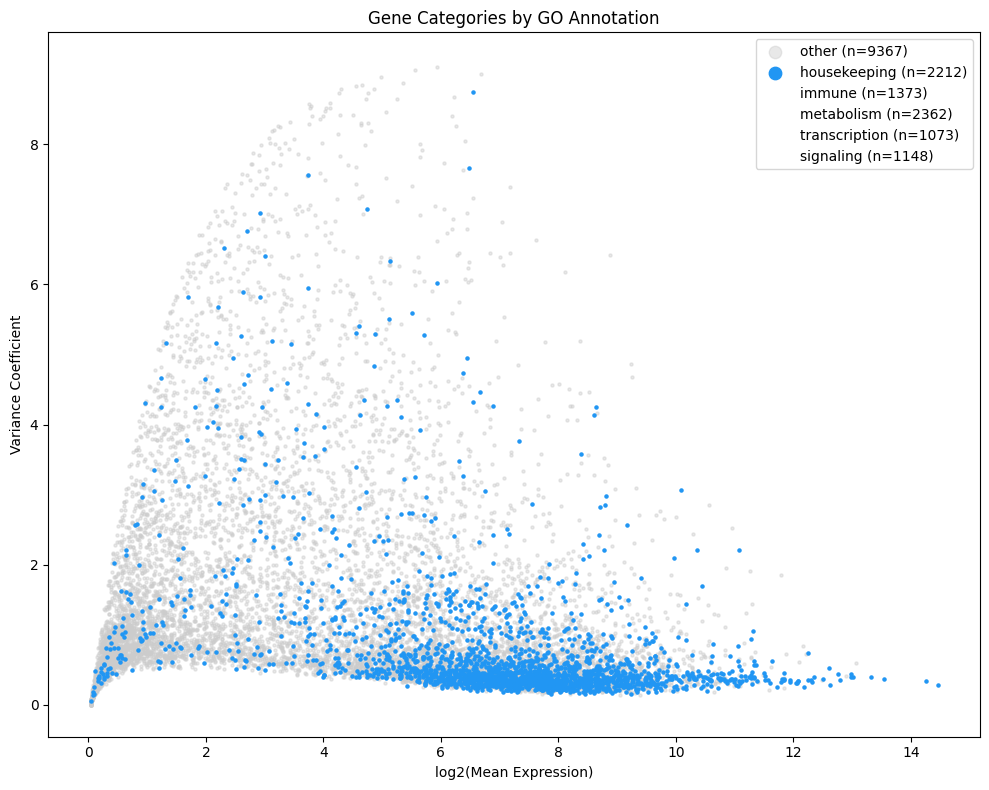

In [81]:
color_map = {
    "housekeeping":  "#2196F370",  
    "immune":        "#F4433670",  
    "metabolism":    "#4CAF5070",  
    "transcription": "#FF980070",  
    "signaling":     "#9C27B070",  
    "other":         "#CCCCCC70",  
}

color_map_housekeeping = {  
    "housekeeping":  "#2196F3",  
    "immune":        "#F4433600",  
    "metabolism":    "#4CAF4F00",  
    "transcription": "#FF990000",  
    "signaling":     "#9B27B000",
    "other":         "#CCCCCC70",  
}

color_map_immune = {
    "housekeeping":  "#CCCCCC00",  
    "immune":        "#F44336",  
    "metabolism":    "#CCCCCC00",  
    "transcription": "#CCCCCC00",  
    "signaling":     "#CCCCCC00",  
    "other":         "#CCCCCC70",  
}

color_map_metabolism = {
    "housekeeping":  "#CCCCCC00",  
    "immune":        "#CCCCCC00",  
    "metabolism":    "#4CAF50",  
    "transcription": "#CCCCCC00",  
    "signaling":     "#CCCCCC00",  
    "other":         "#CCCCCC70",  
}

color_map_transcription = {
    "housekeeping":  "#CCCCCC00",  
    "immune":        "#CCCCCC00",  
    "metabolism":    "#CCCCCC00",  
    "transcription": "#FF9800",  
    "signaling":     "#CCCCCC00",  
    "other":         "#CCCCCC70",  
}

color_map_signaling = {
    "housekeeping":  "#CCCCCC00",  
    "immune":        "#CCCCCC00",  
    "metabolism":    "#CCCCCC00",  
    "transcription": "#CCCCCC00",  
    "signaling":     "#9C27B0",  
    "other":         "#CCCCCC70",  
}


#first plot: log tranformed expression values


fig, ax = plt.subplots(figsize=(10, 8))

for category in ["other"] + [k for k in color_map if k != "other"]:
    group = meanlog2exp_varcoef[meanlog2exp_varcoef["category"] == category]
    ax.scatter(
        group["mean_log2_expression"],
        group["gene_var_coef"],
        c=color_map_housekeeping[category],
        label=f"{category} (n={len(group)})",  
        s=5          
    )

ax.set_xlabel("log2(Mean Expression)")
ax.set_ylabel("Variance Coefficient")
ax.legend(markerscale=4, loc="upper right")
ax.set_title("Gene Categories by GO Annotation")
plt.tight_layout()
plt.show()

plotting without log transformation, but with log scale x-axis<br>
This should give roughly the same plot, but does not change the actual data as with log tranformation.

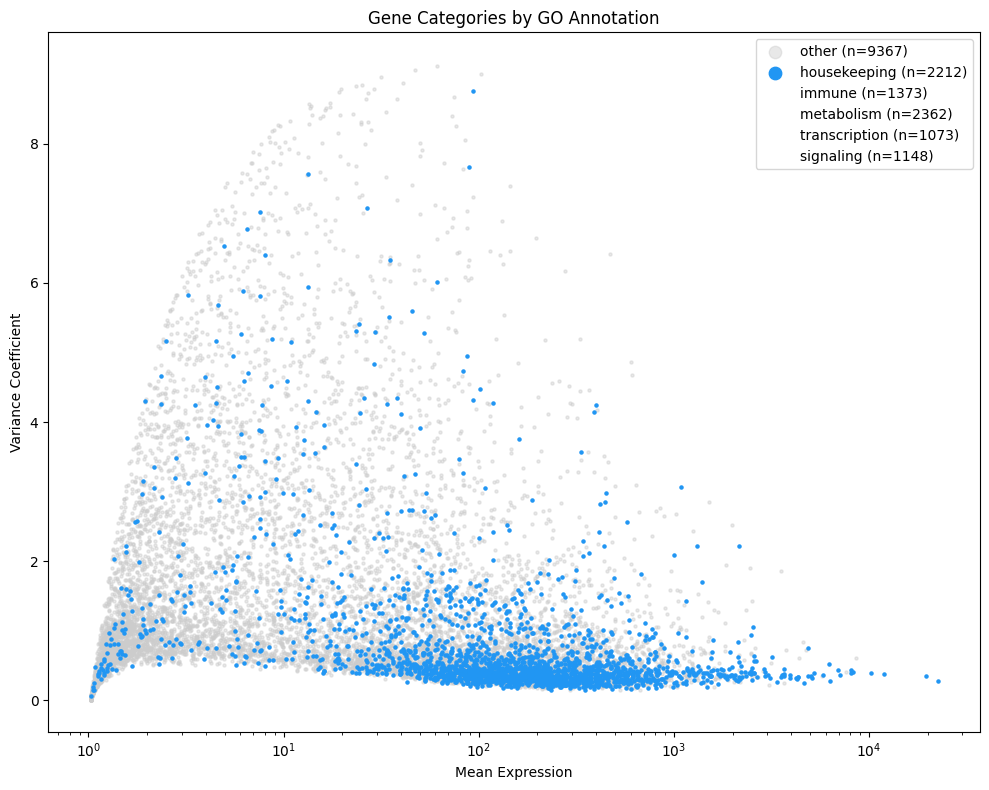

In [82]:
fig, ax = plt.subplots(figsize=(10, 8))

for category in ["other"] + [k for k in color_map if k != "other"]:
    group = meanexp_varcoef[meanexp_varcoef["category"] == category]
    ax.scatter(
        group["mean_expression"],
        group["gene_var_coef"],
        c=color_map_housekeeping[category],
        label=f"{category} (n={len(group)})",  
        s=5          
    )

ax.set_xlabel("Mean Expression")
ax.set_ylabel("Variance Coefficient")
ax.set_xscale("log")
ax.legend(markerscale=4, loc="upper right")
ax.set_title("Gene Categories by GO Annotation")
plt.tight_layout()
plt.show()

plotting with a cutoff at 5000 and 1000 and no log scale<br>
Should make the scatter plot more understandable, because genes with very high mean expression values are no longer included. This is equivalent to zooming in on the left part of the plot.

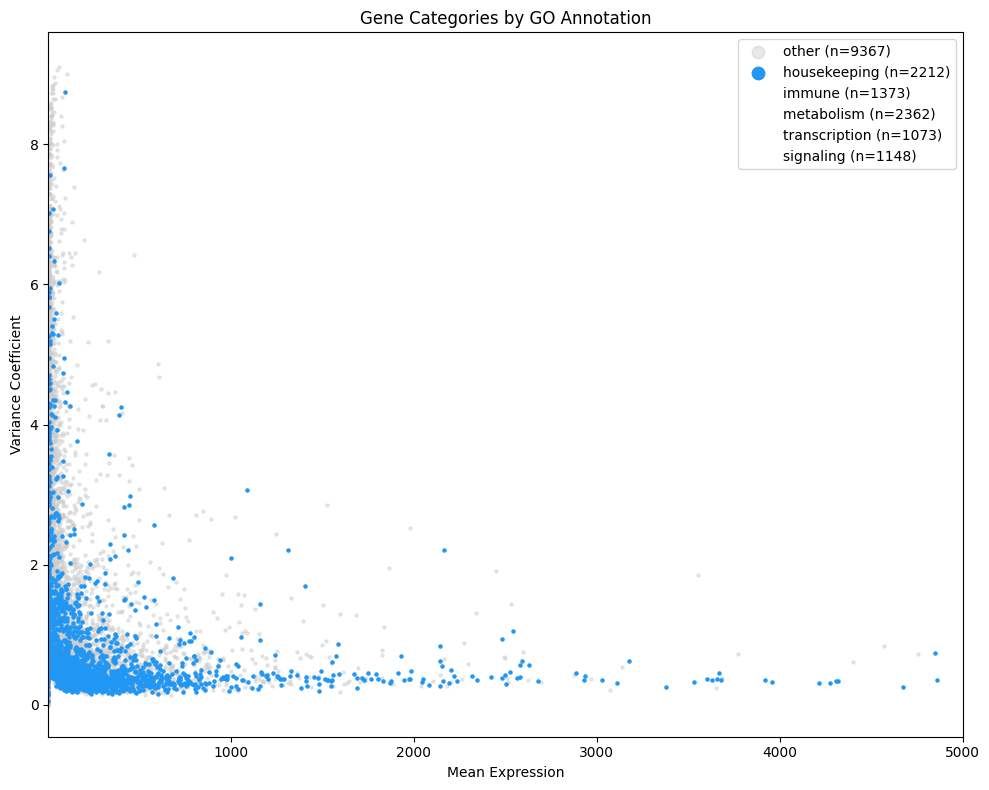

In [83]:
fig, ax = plt.subplots(figsize=(10, 8))

for category in ["other"] + [k for k in color_map if k != "other"]:
    group = meanexp_varcoef[meanexp_varcoef["category"] == category]
    ax.scatter(
        group["mean_expression"],
        group["gene_var_coef"],
        c=color_map_housekeeping[category],
        label=f"{category} (n={len(group)})",  
        s=5          
    )

ax.set_xlabel("Mean Expression")
ax.set_ylabel("Variance Coefficient")
ax.set_xlim(1, 5000)
ax.legend(markerscale=4, loc="upper right")
ax.set_title("Gene Categories by GO Annotation")
plt.tight_layout()
plt.show()

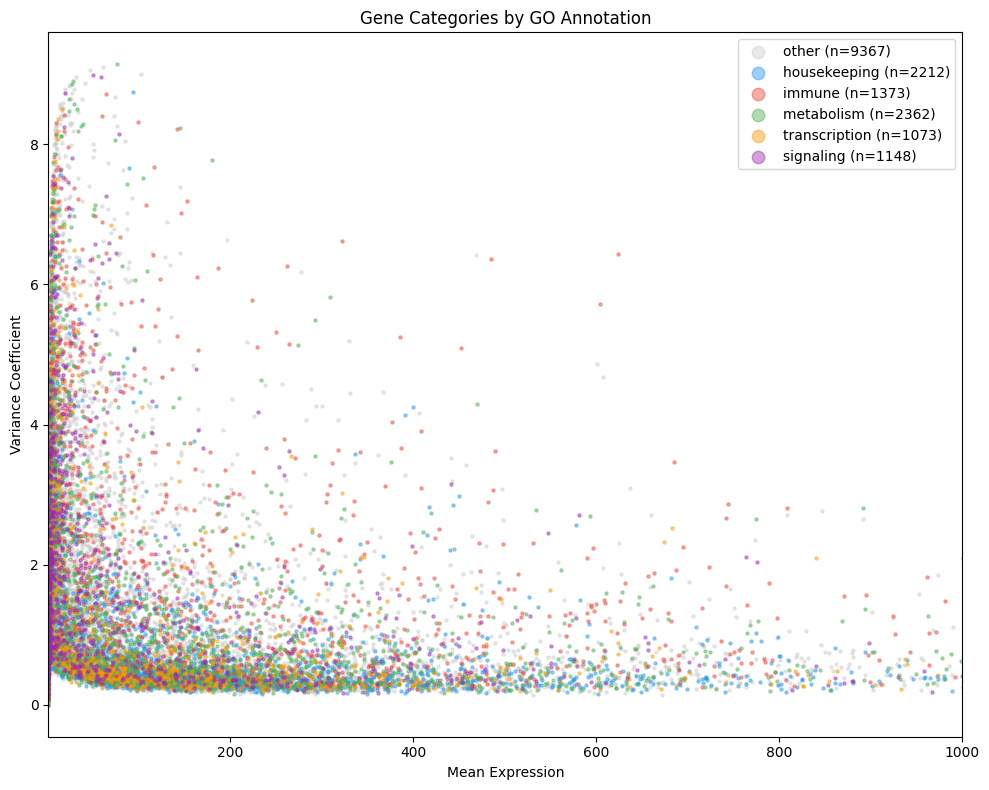

In [84]:
fig, ax = plt.subplots(figsize=(10, 8))

for category in ["other"] + [k for k in color_map if k != "other"]:
    group = meanexp_varcoef[meanexp_varcoef["category"] == category]
    ax.scatter(
        group["mean_expression"],
        group["gene_var_coef"],
        c=color_map[category],
        label=f"{category} (n={len(group)})",  
        s=5          
    )

ax.set_xlabel("Mean Expression")
ax.set_ylabel("Variance Coefficient")
ax.set_xlim(1, 1000)
ax.legend(markerscale=4, loc="upper right")
ax.set_title("Gene Categories by GO Annotation")
plt.tight_layout()
plt.show()